# Speech emotion recognition — Whisper Large V3 / four sources / OSEMN

This replaces the supplied MFCC/CNN workflow while keeping its **four Kaggle paths corrected to your mounted folders**:
RAVDESS, CREMA-D, TESS, and SAVEE. It uses the latest resolved revision of the specifically
requested [`openai/whisper-large-v3`](https://huggingface.co/openai/whisper-large-v3) checkpoint,
pinned below for reproducibility. This is the full Large V3 audio encoder, not Turbo or a
distilled replacement. The transcription decoder is not needed for emotion classification.

**Eight labels:** angry, calm, disgust, fear, happy, neutral, sad, surprise. Calm stays
separate from neutral. TESS's pleasant surprise (`ps`) maps to surprise; this is an explicit
cross-dataset approximation. CREMA-D filename labels describe the intended expression,
which may differ from listener ratings. Dataset/source IDs never enter the model.

Whisper is pretrained for ASR, not these emotion labels. We freeze its audio encoder,
extract ordered audio features, then train and compare a linear head and a regularized
neural head. This is supervised transfer learning, not end-to-end backbone fine-tuning.
The larger dataset warrants a learned nonlinear head; the frozen backbone makes the
experiment practical on a Kaggle GPU. No accuracy is promised or pre-filled.

### Run
Attach all four datasets, enable **Internet + GPU**, start a fresh session, and **Run All**.
The initial download is several GB. Full-dataset Whisper extraction may take hours;
the progress bar estimates remaining time. Batch size reduces automatically on GPU OOM.
No recordings are sampled away to finish faster. Temporary caches can resume within the
same Kaggle session; they are intentionally not published as outputs.

### Only three final files
1. `whisper_ser_deployment.zip`: exact evaluated encoder + frontend + trained head,
   normalization, inference script, manifest, dependencies, model card, and compact data audit.
2. `evaluation.json`: metrics, per-source results, label support, and selection summary.
3. `confusion_matrix.png`: the final held-out confusion matrix.

Intermediate features, candidate checkpoints, raw/augmented audio, training logs, and
decoder weights stay outside `/kaggle/working`. Plots are displayed inline. This notebook
is supplied unexecuted; training, evaluation, and export happen in your Kaggle run.

Path/parser revision: RAVDESS scans the dataset root containing `Actor_01` through `Actor_24`; TESS uses the direct `TESS Toronto emotional speech set data` folder. The four supplied example paths are checked automatically before scanning. Unknown labels still stop the run with their actual filenames in the error message.

Known archive exceptions are handled explicitly: CREMA-D `1040_ITH_SAD_X.wav` retains `sad` (the `X` is an intensity marker); TESS `OAF_neutral/OA_bite_neutral.wav` retains `neutral` and is assigned to `TESS:OAF`, not a third speaker. These cases were checked against Kaggle file listings. No emotion is guessed for unmatched filenames.


In [5]:
# Install before imports. Keep Kaggle's matched CUDA/PyTorch installation.
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.49.0', 'accelerate==1.4.0', 'huggingface-hub==0.36.2',
    'safetensors>=0.4.3,<1', 'librosa==0.11.0', 'soundfile==0.13.1',
    'scikit-learn==1.6.1', 'imageio-ffmpeg==0.6.0'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.2 MB/s eta 0:00:00


0

## O — Obtain: explicit paths and settings
The checkpoint revision is pinned; the Transformers version is a deliberate compatibility
pin, not a claim that it is the newest library release. Change only the paths if Kaggle
mounts a different folder. Do not repeatedly search seeds using test accuracy.

In [6]:
from pathlib import Path
import os, sys, re, json, hashlib, random, gc, shutil, zipfile, platform, importlib.metadata
os.environ['USE_TF'] = '0'
os.environ['USE_FLAX'] = '0'
os.environ['HF_HUB_DISABLE_XET'] = '1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from scipy.optimize import minimize_scalar
from IPython.display import display, FileLink
from tqdm.auto import tqdm
from safetensors.torch import save_file, load_file

PATHS = {
 'RAVDESS': Path('/kaggle/input/ravdess-emotional-speech-audio/'),
 'CREMA-D': Path('/kaggle/input/cremad/AudioWAV/'),
 'TESS': Path('/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/'),
 'SAVEE': Path('/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/'),
}
LABELS = ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
SEED = 42
MODEL_ID = 'openai/whisper-large-v3'
REVISION = '06f233fe06e710322aca913c1bc4249a0d71fce1'
CONFIG = {'sample_rate': 16000, 'min_seconds': .35, 'max_seconds': 120.,
          'min_rms': 1e-5, 'trim_db': 35., 'trim_margin_seconds': .15,
          'chunk_seconds': 30, 'encoder_batch_size': 4, 'normalization_clip': 8.}
MAX_EPOCHS, PATIENCE, HEAD_BATCH_SIZE = 60, 10, 128
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    raise RuntimeError('Enable a Kaggle GPU, restart the session, then Run All.')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(2)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
OUT = Path('/kaggle/working')
TEMP = Path('/kaggle/temp/whisper_ser_four_sources')
ENCODER = TEMP / 'encoder'
STAGING = TEMP / 'deployment'
for directory in [OUT, TEMP, ENCODER, STAGING]: directory.mkdir(parents=True, exist_ok=True)
packages = ['numpy', 'pandas', 'scipy', 'torch', 'transformers', 'accelerate',
            'huggingface-hub', 'safetensors', 'librosa', 'soundfile', 'soxr', 'scikit-learn', 'imageio-ffmpeg']
VERSIONS = {name: importlib.metadata.version(name) for name in packages}
missing = {name: str(path) for name, path in PATHS.items() if not path.is_dir()}
if missing: raise FileNotFoundError('Attach the missing datasets or correct PATHS: ' + str(missing))
print('Backbone:', MODEL_ID, '@', REVISION)
print('GPU:', torch.cuda.get_device_name(0))

Backbone: openai/whisper-large-v3 @ 06f233fe06e710322aca913c1bc4249a0d71fce1
GPU: Tesla T4


## S — Scrub: fix leakage and use one audio contract
The supplied notebook created augmented relatives **before** random splitting and used
the test set as validation during training. That makes the old reported score unsuitable
for comparison with a genuinely speaker-separated evaluation. Its scaler already fitted
training rows; that part was not missing. The fixed 0.6-second offset / 2.5-second crop,
fragile label parsing, and global sample-rate variable are removed here.

Use full recordings, anti-aliased resampling, DC removal, phase-aware stereo downmix, and
boundary-only silence trimming with a margin. Preserve internal pauses. Flag clipping
and very low-energy audio; clipping alone does not cause exclusion. Reject unreadable,
nonfinite, silent, or unsupported-length recordings using fixed thresholds. Do not apply
aggressive denoising, pitch/speed changes, per-clip RMS equalization, or synthetic oversampling.
Those are not automatically label preserving. Whisper uses its own 128-bin log-mel frontend
with waveform normalization disabled. All learned feature scaling is fitted on training only.

Exact hashes are computed on decoded/resampled/DC-centered audio before trimming.
Identical audio with conflicting labels is quarantined; identical same-label copies are
deduplicated. This is not a guarantee of detecting re-encoded or altered duplicates.
Source speaker identifiers are namespaced; the evaluation assumes a person does not occur
under different identities across corpora, which these metadata cannot independently verify.

In [7]:
RUNTIME_SOURCE = r'''
"""Shared Whisper Large V3 preprocessing, encoder, emotion head, and offline inference."""
from pathlib import Path
import os, json, hashlib, subprocess
os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')
import numpy as np
import soundfile as sf
import librosa
import torch
from torch import nn


def load_audio(path, config):
    path = Path(path)
    if not path.is_file(): raise FileNotFoundError(path)
    sr_target = config['sample_rate']
    if path.suffix.lower() in {'.wav', '.flac', '.aif', '.aiff'}:
        info = sf.info(str(path))
        if not config['min_seconds'] <= info.duration <= config['max_seconds']:
            raise ValueError('Unsupported duration')
        wave, sr = sf.read(str(path), always_2d=True, dtype='float32')
        if not len(wave) or not np.isfinite(wave).all(): raise ValueError('Nonfinite or empty audio')
        clipping = float(np.mean(np.abs(wave) >= .999))
        mono = wave.mean(axis=1)
        if wave.shape[1] > 1:
            energies = np.mean(wave.astype(np.float64)**2, axis=0)
            if float(np.mean(mono.astype(np.float64)**2)) < .01 * energies.max():
                mono = wave[:, int(energies.argmax())]
        if sr != sr_target:
            mono = librosa.resample(mono, orig_sr=sr, target_sr=sr_target, res_type='soxr_hq')
    else:
        import imageio_ffmpeg
        result = subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), '-nostdin', '-v', 'error',
            '-i', str(path), '-t', str(config['max_seconds'] + 1), '-f', 'f32le',
            '-acodec', 'pcm_f32le', '-ac', '1', '-ar', str(sr_target), 'pipe:1'],
            capture_output=True, timeout=90)
        if result.returncode: raise ValueError('Audio decoding failed')
        mono = np.frombuffer(result.stdout, dtype='<f4').copy()
        clipping = float(np.mean(np.abs(mono) >= .999)) if len(mono) else 0.
    if not len(mono) or not np.isfinite(mono).all(): raise ValueError('Nonfinite or empty audio')
    mono = np.asarray(mono - mono.mean(), dtype=np.float32)
    duration = len(mono) / sr_target
    rms = float(np.sqrt(np.mean(mono.astype(np.float64)**2)))
    if not config['min_seconds'] <= duration <= config['max_seconds']: raise ValueError('Unsupported duration')
    if rms < config['min_rms']: raise ValueError('Silent or too quiet')
    digest = hashlib.sha256(mono.astype('<f4').tobytes()).hexdigest()
    _, boundaries = librosa.effects.trim(mono, top_db=config['trim_db'], frame_length=1024, hop_length=160)
    margin = round(config['trim_margin_seconds'] * sr_target)
    start, end = max(0, int(boundaries[0])-margin), min(len(mono), int(boundaries[1])+margin)
    clean = np.ascontiguousarray(mono[start:end], dtype=np.float32)
    if len(clean) < config['min_seconds'] * sr_target: raise ValueError('Insufficient usable audio')
    return clean, {'audio_hash': digest, 'duration': duration, 'retained_seconds': len(clean)/sr_target,
                   'rms': rms, 'clipping_fraction': clipping}


def audio_chunks(audio, config):
    size = int(config['chunk_seconds'] * config['sample_rate'])
    if not 0 < size <= 480000: raise ValueError('Whisper window must be <=30 seconds')
    pieces = [audio[i:i+size] for i in range(0, len(audio), size)]
    if len(pieces) > 1 and len(pieces[-1]) < 8000:
        tail = np.r_[pieces[-2], pieces[-1]]
        mid = len(tail)//2
        pieces[-2:] = [tail[:mid], tail[mid:]]
    assert sum(map(len, pieces)) == len(audio) and max(map(len, pieces)) <= size
    return pieces


class WhisperFeatures:
    def __init__(self, encoder_dir, config, device='cpu'):
        from transformers import WhisperFeatureExtractor
        from transformers.models.whisper.modeling_whisper import WhisperEncoder
        self.config, self.device = config, device
        dtype = torch.float16 if str(device).startswith('cuda') else torch.float32
        self.frontend = WhisperFeatureExtractor.from_pretrained(encoder_dir, local_files_only=True)
        self.encoder, info = WhisperEncoder.from_pretrained(encoder_dir, local_files_only=True,
            torch_dtype=dtype, low_cpu_mem_usage=True, use_safetensors=True,
            attn_implementation='sdpa', output_loading_info=True)
        if any(info.get(k) for k in ['missing_keys', 'unexpected_keys', 'mismatched_keys', 'error_msgs']):
            raise RuntimeError('Encoder key mismatch: ' + str(info))
        c = self.encoder.config
        if (c.encoder_layers, c.d_model, c.num_mel_bins) != (32, 1280, 128):
            raise ValueError('Expected the full Whisper Large V3 encoder')
        if (self.frontend.sampling_rate, self.frontend.feature_size, self.frontend.n_samples) != (16000,128,480000):
            raise ValueError('Incorrect Whisper frontend')
        self.encoder.requires_grad_(False).eval().to(device)
        self.effective_batch_size = config['encoder_batch_size']

    def extract_many(self, waveforms):
        windows = [(i,piece) for i,wave in enumerate(waveforms) for piece in audio_chunks(wave,self.config)]
        collected = [[] for _ in waveforms]
        position, batch_size = 0, self.effective_batch_size
        dtype = next(self.encoder.parameters()).dtype
        while position < len(windows):
            batch = windows[position:position+batch_size]
            # Separate frontend calls guarantee sample-local mel scaling regardless of batching.
            inputs = [self.frontend(piece, sampling_rate=16000, return_tensors='pt',
                padding='max_length', max_length=480000, truncation=True,
                return_attention_mask=True, do_normalize=False) for _,piece in batch]
            lengths = [min(1500,(int(x.attention_mask.sum())+1)//2) for x in inputs]
            mel = torch.cat([x.input_features for x in inputs],dim=0)
            if tuple(mel.shape[1:]) != (128,3000): raise RuntimeError('Incorrect Whisper mel shape')
            hidden = None
            try:
                with torch.inference_mode():
                    hidden = self.encoder(mel.to(self.device,dtype=dtype),return_dict=True).last_hidden_state
            except torch.cuda.OutOfMemoryError:
                if batch_size == 1: raise
                del hidden, mel, inputs
                torch.cuda.empty_cache()
                batch_size = max(1,batch_size//2)
                self.effective_batch_size = batch_size
                continue
            for j, ((owner,_), length) in enumerate(zip(batch,lengths)):
                if length < 4: raise ValueError('Too few real frames')
                collected[owner].append(hidden[j,:length].to(device='cpu',dtype=torch.float32))
            position += len(batch)
            del hidden, mel, inputs
        rows = []
        for parts in collected:
            frames = torch.cat(parts,dim=0)
            mean = frames.mean(0)
            std = frames.std(0,unbiased=False)
            quarters = torch.stack([part.mean(0) for part in torch.tensor_split(frames,4)])
            vector = torch.cat([mean,std,(quarters-mean[None]).flatten()]).numpy()
            if vector.shape != (7680,) or not np.isfinite(vector).all(): raise ValueError('Invalid Whisper features')
            rows.append(vector)
        return np.stack(rows)


class EmotionHead(nn.Module):
    def __init__(self, input_dim, num_labels, hidden_dim=256, dropout=.4):
        super().__init__()
        if hidden_dim == 0:
            self.net = nn.Sequential(nn.Dropout(dropout),nn.Linear(input_dim,num_labels))
        else:
            self.net = nn.Sequential(nn.Linear(input_dim,hidden_dim),nn.LayerNorm(hidden_dim),
                nn.GELU(),nn.Dropout(dropout),nn.Linear(hidden_dim,128),nn.GELU(),
                nn.Dropout(dropout/2),nn.Linear(128,num_labels))
    def forward(self,x): return self.net(x)


def normalize_features(X, mean, scale, clip):
    return np.clip((np.asarray(X,dtype=np.float32)-mean)/scale,-clip,clip).astype(np.float32)


def probabilities(logits, temperature):
    values = np.asarray(logits,dtype=np.float64)/float(temperature)
    values -= values.max(axis=1,keepdims=True)
    exp = np.exp(values)
    return exp/exp.sum(axis=1,keepdims=True)


class EmotionPredictor:
    def __init__(self, bundle, device='cpu'):
        from safetensors.torch import load_file
        root = Path(bundle)
        self.manifest = json.loads((root/'manifest.json').read_text())
        self.config, self.labels = self.manifest['audio_config'],self.manifest['labels']
        self.device = device
        self.features = WhisperFeatures(root/'encoder',self.config,device)
        with np.load(root/'normalization.npz',allow_pickle=False) as z:
            self.mean,self.scale = z['mean'],z['scale']
        self.head = EmotionHead(**self.manifest['head'])
        self.head.load_state_dict(load_file(str(root/'classifier.safetensors')),strict=True)
        self.head.eval().to(device)
    def predict(self, audio_path):
        wave, stats = load_audio(audio_path,self.config)
        x = self.features.extract_many([wave])
        x = normalize_features(x,self.mean,self.scale,self.config['normalization_clip'])
        with torch.inference_mode(): logits = self.head(torch.from_numpy(x).to(self.device)).float().cpu().numpy()
        p = probabilities(logits,self.manifest['temperature'])[0]
        best = int(p.argmax())
        return {'emotion':self.labels[best], 'confidence':float(p[best]),
                'probabilities':dict(zip(self.labels,map(float,p))), 'duration_seconds':stats['duration']}


if __name__ == '__main__':
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument('--bundle',required=True)
    parser.add_argument('--audio',required=True)
    parser.add_argument('--device',default='cpu')
    args = parser.parse_args()
    torch.set_num_threads(2)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    print(json.dumps(EmotionPredictor(args.bundle,args.device).predict(args.audio)))
'''
RUNTIME_PATH = TEMP / 'predict.py'
RUNTIME_PATH.write_text(RUNTIME_SOURCE,encoding='utf-8')
if str(TEMP) not in sys.path: sys.path.insert(0,str(TEMP))
import importlib
import predict as runtime
importlib.reload(runtime)
from predict import load_audio, WhisperFeatures, EmotionHead, normalize_features, probabilities, EmotionPredictor

In [8]:
RAV_LABELS = {'01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fear','07':'disgust','08':'surprise'}
CREMA_LABELS = {'ANG':'angry','DIS':'disgust','FEA':'fear','HAP':'happy','NEU':'neutral','SAD':'sad'}
SAVEE_LABELS = {'a':'angry','d':'disgust','f':'fear','h':'happy','n':'neutral','sa':'sad','su':'surprise'}
def parse_name(source, path):
    stem = path.stem
    if source == 'RAVDESS':
        m = re.fullmatch(r'03-01-(0[1-8])-(0[12])-(0[12])-(0[12])-([0-9]{2})',stem)
        if not m or not 1 <= int(m[5]) <= 24: raise ValueError('Expected RAVDESS audio-only speech filename')
        label,speaker = RAV_LABELS[m[1]],m[5]
    elif source == 'CREMA-D':
        m = re.fullmatch(r'([0-9]{4})_([A-Z0-9]+)_(ANG|DIS|FEA|HAP|NEU|SAD)_(LO|MD|HI|XX|X)',stem.upper())
        if not m: raise ValueError('Unknown CREMA-D filename')
        label,speaker = CREMA_LABELS[m[3]],m[1]
    elif source == 'TESS':
        m = re.fullmatch(r'(OAF|YAF|OA)_(.+)_(angry|disgust|fear|happy|neutral|sad|ps)',stem,re.I)
        if not m: raise ValueError('Unknown TESS filename')
        label,speaker = ('surprise' if m[3].lower()=='ps' else m[3].lower()),m[1].upper()
        # Documented archive typo: OA_bite_neutral.wav is in the OAF_neutral folder.
        # Require both the exact file and folder before assigning it to the OAF speaker.
        if speaker == 'OA':
            if path.name.lower() != 'oa_bite_neutral.wav' or path.parent.name.lower() != 'oaf_neutral':
                raise ValueError('Unknown TESS OA speaker alias; expected the documented OAF_neutral file')
            speaker = 'OAF'
        folder = path.parent.name.upper()
        if folder.startswith(('OAF_', 'YAF_')) and folder.split('_', 1)[0] != speaker:
            raise ValueError('TESS filename and parent-folder speaker disagree')
    elif source == 'SAVEE':
        m = re.fullmatch(r'(DC|JE|JK|KL)_(sa|su|a|d|f|h|n)([0-9]+)',stem,re.I)
        if not m: raise ValueError('Unknown SAVEE filename')
        label,speaker = SAVEE_LABELS[m[2].lower()],m[1].upper()
    else: raise ValueError('Unknown corpus')
    return label,source + ':' + speaker

# Fail early if an old/stale parser cell is still loaded in this kernel.
PARSER_EXAMPLES = [
 ('RAVDESS', '/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav', 'neutral', 'RAVDESS:01'),
 ('SAVEE', '/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_a01.wav', 'angry', 'SAVEE:DC'),
 ('TESS', '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Fear/OAF_back_fear.wav', 'fear', 'TESS:OAF'),
 ('CREMA-D', '/kaggle/input/cremad/AudioWAV/1001_DFA_ANG_XX.wav', 'angry', 'CREMA-D:1001'),
]
PARSER_EXAMPLES += [
 ('CREMA-D', '/kaggle/input/cremad/AudioWAV/1040_ITH_SAD_X.wav', 'sad', 'CREMA-D:1040'),
 ('TESS', '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_neutral/OA_bite_neutral.wav', 'neutral', 'TESS:OAF'),
]
for source, filename, label, speaker in PARSER_EXAMPLES:
    assert parse_name(source, Path(filename)) == (label, speaker), filename
rows, parsing_errors, ignored_metadata = [],[],[]
for source,root in PATHS.items():
    files = sorted(p for p in root.rglob('*') if p.is_file() and p.suffix.lower()=='.wav')
    if not files: raise FileNotFoundError('No WAV files under ' + str(root))
    for path in files:
        # AppleDouble resource forks are metadata, even when their names end in .wav.
        if path.name.startswith('._') or '__MACOSX' in path.parts:
            ignored_metadata.append(str(path))
            continue
        try: label,speaker = parse_name(source,path)
        except ValueError as error:
            parsing_errors.append({'source':source,'file':str(path),'error':str(error)})
            continue
        rows.append({'source':source,'relative_path':path.relative_to(root).as_posix(),
                     'path':str(path),'speaker':speaker,'label':label,'status':'pending'})
if parsing_errors:
    errors = pd.DataFrame(parsing_errors)
    display(errors.groupby('source').size().to_frame('unrecognized_files'))
    print(errors.head(20).to_string(index=False))
    details = '; '.join(f"{entry['source']}: {entry['file']} ({entry['error']})" for entry in parsing_errors[:8])
    raise ValueError(f'{len(parsing_errors)} unrecognized filenames. First actual failures: {details}')
print(f'Parsed {len(rows)} audio paths; ignored {len(ignored_metadata)} AppleDouble/macOS metadata entries.')
audit = pd.DataFrame(rows).sort_values(['source','relative_path']).reset_index(drop=True)
for i,row in tqdm(audit.iterrows(),total=len(audit),desc='Decode and quality audit'):
    try:
        _,stats = load_audio(row.path,CONFIG)
        for key,value in stats.items(): audit.loc[i,key] = value
        audit.loc[i,'status'] = 'accepted'
    except (ValueError,RuntimeError,OSError,subprocess.SubprocessError) as error:
        audit.loc[i,'status'] = 'rejected_audio'
        audit.loc[i,'reason'] = str(error)[:200]

good = audit[audit.status=='accepted']
if good.empty: raise ValueError('No audio passed the quality audit; inspect paths and source files')
conflicts = set(good.groupby('audio_hash').label.nunique().loc[lambda x:x>1].index)
audit.loc[audit.audio_hash.isin(conflicts),'status'] = 'conflicting_labels'
good = audit[audit.status=='accepted']
duplicates = good[good.duplicated('audio_hash',keep='first')].index
audit.loc[duplicates,'status'] = 'duplicate_audio'
display(pd.crosstab(audit.source,audit.status))
bad_fraction = audit.status.isin(['rejected_audio','conflicting_labels']).groupby(audit.source).mean()
if (bad_fraction>.05).any(): raise ValueError('More than 5% unusable/conflicting audio in a source; inspect the displayed audit before proceeding.')
data = audit[audit.status=='accepted'].copy().reset_index(drop=True)
if set(data.label) != set(LABELS): raise ValueError('The cleaned dataset lacks a required class')
if set(data.source) != set(PATHS): raise ValueError('A source has no accepted recordings')
print('Accepted originals:',len(data),'; source-qualified speakers:',data.speaker.nunique())

Parsed 13602 audio paths; ignored 0 AppleDouble/macOS metadata entries.


Decode and quality audit:   0%|          | 0/13602 [00:00<?, ?it/s]

status,accepted,conflicting_labels,duplicate_audio,rejected_audio
source,,,,
CREMA-D,7435,6,0,1
RAVDESS,1439,0,1441,0
SAVEE,480,0,0,0
TESS,2800,0,0,0


Accepted originals: 12154 ; source-qualified speakers: 121


### Speaker-separated split, with an explicit TESS exception
For sources with at least three speakers, assign approximately 70% / 15% / 15% of speakers
to train / validation / test, using a seeded order and at least one speaker in each part.
TESS has only two speakers: one goes to training and one to test, with **no TESS validation
speaker**. Splitting its two people into three disjoint sets is impossible. Model selection
and confidence calibration therefore have no direct TESS validation coverage.

All utterances of each speaker stay together. Exact audio hashes cannot cross partitions.
Shared scripted sentences may occur in different partitions: this evaluates new speakers
within these sources, not unseen sentences or new recording domains. Calm occurs only in
RAVDESS, and source label inventories differ; inspect source-specific metrics before
interpreting pooled accuracy. No source identity is a classifier input.

In [9]:
assignment = {}
for source in sorted(PATHS):
    speakers = np.array(sorted(data.loc[data.source==source,'speaker'].unique()))
    source_seed = SEED + int(hashlib.sha256(source.encode()).hexdigest()[:8],16)
    speakers = np.random.default_rng(source_seed).permutation(speakers)
    n = len(speakers)
    if n < 2: raise ValueError(f'{source} has fewer than two speakers')
    if source == 'TESS' and n == 2:
        counts = (1,0,1)
    else:
        if n < 3: raise ValueError(f'{source} cannot support three speaker-separated partitions')
        nval,ntest = max(1,round(.15*n)),max(1,round(.15*n))
        counts = (n-nval-ntest,nval,ntest)
    a,b = counts[0],counts[0]+counts[1]
    for part,names in zip(['train','validation','test'],[speakers[:a],speakers[a:b],speakers[b:]]):
        assignment.update({str(name):part for name in names})
data['split'] = data.speaker.map(assignment)
audit['split'] = 'excluded'
lookup = data.set_index(['source','relative_path'])['split']
for idx,row in audit[audit.status=='accepted'].iterrows():
    audit.loc[idx,'split'] = lookup.loc[(row.source,row.relative_path)]
indices = {part:np.flatnonzero(data.split.to_numpy()==part) for part in ['train','validation','test']}
for part,ids in indices.items():
    if not len(ids) or set(data.iloc[ids].label)!=set(LABELS):
        raise ValueError(f'{part} is empty or lacks one of eight classes; inspect source availability without tuning seeds by scores')
for first,second in [('train','validation'),('train','test'),('validation','test')]:
    for key in ['speaker','audio_hash']:
        assert set(data.iloc[indices[first]][key]).isdisjoint(data.iloc[indices[second]][key])
display(data.groupby(['source','split']).agg(recordings=('label','size'),speakers=('speaker','nunique')))
display(pd.crosstab([data.source,data.split],data.label).reindex(columns=LABELS,fill_value=0))

recordings  speakers
source  split                           
CREMA-D test              1142        14
        train             5148        63
        validation        1145        14
RAVDESS test               240         4
        train              960        16
        validation         239         4
SAVEE   test               120         1
        train              240         2
        validation         120         1
TESS    test              1400         1
        train             1400         1

label               angry  calm  disgust  fear  happy  neutral  sad  surprise
source  split                                                                
CREMA-D test          195     0      195   195    195      167  195         0
        train         879     0      880   879    879      752  879         0
        validation    196     0      195   196    196      167  195         0
RAVDESS test           32    32       32    32     32       16   32        32
        train         128   128      128   128    128       64  128       128
        validation     32    32       32    32     31       16   32        32
SAVEE   test           15     0       15    15     15       30   15        15
        train          30     0       30    30     30       60   30        30
        validation     15     0       15    15     15       30   15        15
TESS    test          200     0      200   200    200      200  200       200
        train         200     0      200   200    200      200  200       200

## E — Explore development audio only
Class/source counts expose corpus imbalance. Duration and clipping summaries flag recording
conditions; these flags do not authorize discarding difficult test cases after seeing scores.
The fixed cleaning policy above is used unchanged at deployment.

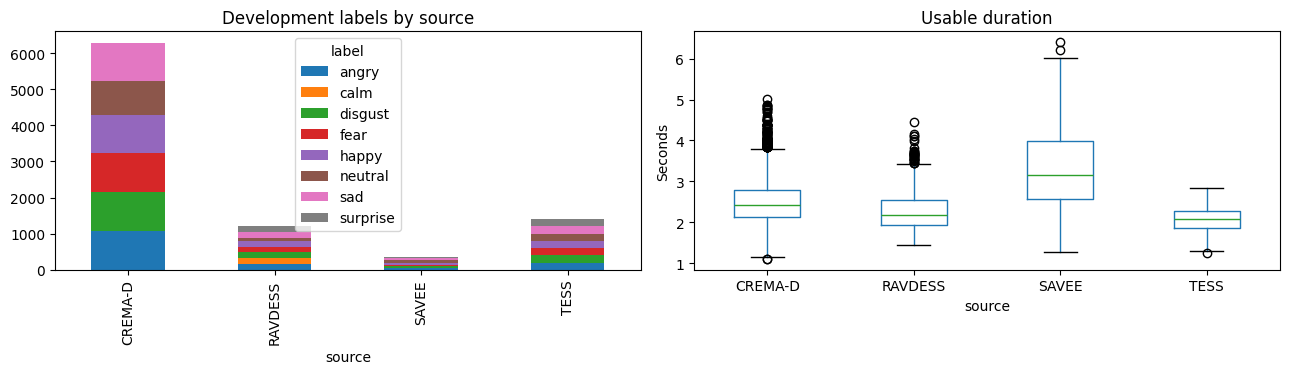

,rms,clipping_fraction,retained_seconds
source,,,
CREMA-D,0.022762,0.0,2.435750
RAVDESS,0.009508,0.0,2.170000
SAVEE,0.132466,0.0,3.150000
TESS,0.043126,0.0,2.072156


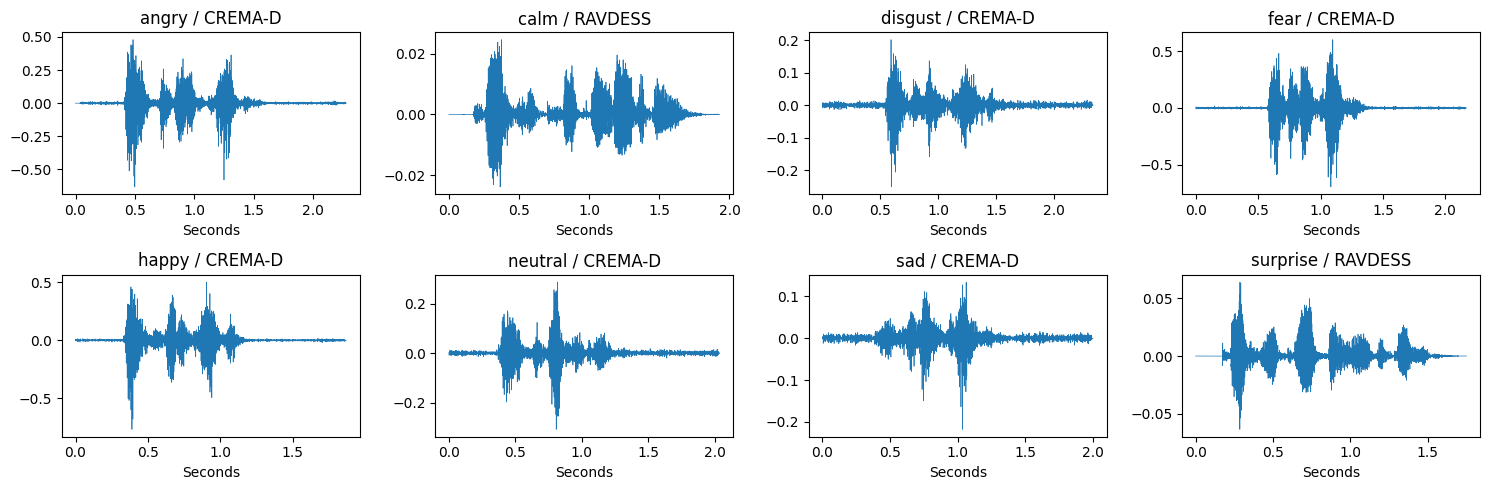

In [10]:
development = data[data.split!='test']
fig,axes = plt.subplots(1,2,figsize=(13,4))
pd.crosstab(development.source,development.label).reindex(columns=LABELS,fill_value=0).plot.bar(stacked=True,ax=axes[0])
axes[0].set_title('Development labels by source')
development.boxplot(column='retained_seconds',by='source',ax=axes[1],grid=False)
axes[1].set_title('Usable duration'); axes[1].set_ylabel('Seconds')
plt.suptitle(''); plt.tight_layout(); plt.show()
display(development.groupby('source')[['rms','clipping_fraction','retained_seconds']].median())
fig,axes = plt.subplots(2,4,figsize=(15,5))
for ax,label in zip(axes.flat,LABELS):
    row = development[development.label==label].iloc[0]
    wave,_ = load_audio(row.path,CONFIG)
    step = max(1,len(wave)//6000)
    ax.plot(np.arange(len(wave))[::step]/16000,wave[::step],lw=.5)
    ax.set(title=label+' / '+row.source,xlabel='Seconds')
plt.tight_layout(); plt.show()

## M — Model: full Whisper Large V3 encoder + supervised emotion head
Load the verified 32-layer, width-1280 encoder from the pinned Hugging Face checkpoint.
Its own frontend produces 128 × 3000 log-mel inputs per window. We exclude right-padding
positions from **pooling**, accounting for convolution stride. The pinned encoder does
not support masking its internal attention; padding can still influence real-frame states.

For each recording, concatenate the mean, standard deviation, and four ordered quarter-mean
contrasts of the real frame representations: 7,680 features. These preserve both overall
voice information and coarse changes over time. No audio is chopped into independent
labeled training examples. The head learns eight labels from Whisper features; this is
not transcription sentiment analysis or zero-shot emotion prediction.

Cached frozen features make head training inexpensive. Standardization and a fixed ±8
standard-deviation cap are learned/applied from training data only. Compare a linear head
with a 256→128-unit GELU head. AdamW, dropout, mild label smoothing, clipped gradients,
and early stopping reduce overfitting; they do not guarantee its absence. A capped
inverse-square-root class weight supports rare classes without duplicating samples.

In [11]:
from transformers import WhisperModel, WhisperFeatureExtractor
identity = {'model_id':MODEL_ID,'revision':REVISION,'transformers':VERSIONS['transformers']}
identity_path = ENCODER/'identity.json'
if identity_path.exists():
    if json.loads(identity_path.read_text()) != identity or not (ENCODER/'model.safetensors').is_file():
        raise RuntimeError('Incomplete or different encoder cache; choose a new TEMP directory')
else:
    frontend = WhisperFeatureExtractor.from_pretrained(MODEL_ID,revision=REVISION,cache_dir=TEMP/'hf_cache')
    backbone,info = WhisperModel.from_pretrained(MODEL_ID,revision=REVISION,cache_dir=TEMP/'hf_cache',
        torch_dtype=torch.float16,low_cpu_mem_usage=True,use_safetensors=True,
        attn_implementation='sdpa',output_loading_info=True)
    if any(info.get(k) for k in ['missing_keys','mismatched_keys','error_msgs']) or any('encoder.' in k for k in info.get('unexpected_keys',[])):
        raise RuntimeError('Incomplete Whisper checkpoint: '+str(info))
    enc = backbone.get_encoder().requires_grad_(False).eval()
    assert (enc.config.encoder_layers,enc.config.d_model,enc.config.num_mel_bins)==(32,1280,128)
    enc.save_pretrained(ENCODER,safe_serialization=True,max_shard_size='4GB')
    frontend.save_pretrained(ENCODER)
    identity_path.write_text(json.dumps(identity,indent=2))
    del enc,backbone,frontend
    gc.collect()
extractor = WhisperFeatures(ENCODER,CONFIG,DEVICE)

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:397: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'max_length': 448, 'begin_suppress_tokens': [220, 50257]}
  warnings.warn(


In [12]:
# One temporary feature matrix and completion mask; no feature CSVs or thousands of outputs.
fingerprint = hashlib.sha256((RUNTIME_SOURCE+json.dumps(CONFIG,sort_keys=True)+REVISION+
    json.dumps(VERSIONS,sort_keys=True)+data[['source','relative_path','audio_hash']].to_csv(index=False)).encode()).hexdigest()
cache = TEMP/('features_'+fingerprint[:20]); cache.mkdir(exist_ok=True)
matrix_path,done_path = cache/'features.npy',cache/'complete.npy'
if matrix_path.exists() != done_path.exists(): raise RuntimeError('Incomplete feature cache pair; use a new TEMP directory')
if matrix_path.exists():
    features = np.load(matrix_path,mmap_mode='r+')
    done = np.load(done_path,mmap_mode='r+')
    assert features.shape==(len(data),7680) and done.shape==(len(data),)
else:
    features = np.lib.format.open_memmap(matrix_path,mode='w+',dtype=np.float32,shape=(len(data),7680))
    done = np.lib.format.open_memmap(done_path,mode='w+',dtype=np.bool_,shape=(len(data),))
    done[:] = False; done.flush()
def ensure_features(ids, description):
    pending = [int(i) for i in ids if not done[i]]
    with tqdm(total=len(pending),desc=description,unit='clip') as progress:
        for start in range(0,len(pending),CONFIG['encoder_batch_size']):
            batch = pending[start:start+CONFIG['encoder_batch_size']]
            waves = [load_audio(data.iloc[i].path,CONFIG)[0] for i in batch]
            result = extractor.extract_many(waves)
            features[batch] = result
            features.flush()  # Mark complete only after the corresponding features are flushed.
            done[batch] = True; done.flush()
            progress.update(len(batch))
ensure_features(np.r_[indices['train'],indices['validation']],'Whisper development features')
# Test features are not extracted until both the head and temperature are fixed.
train_ids,val_ids = indices['train'],indices['validation']
normal_mean = np.mean(features[train_ids],axis=0,dtype=np.float64).astype(np.float32)
normal_scale = np.std(features[train_ids],axis=0,dtype=np.float64).astype(np.float32)
normal_scale[normal_scale<1e-5] = 1.
X_train = normalize_features(features[train_ids],normal_mean,normal_scale,CONFIG['normalization_clip'])
X_val = normalize_features(features[val_ids],normal_mean,normal_scale,CONFIG['normalization_clip'])
y = np.array([LABELS.index(label) for label in data.label])
y_train,y_val = y[train_ids],y[val_ids]
print('Training/validation shapes:',X_train.shape,X_val.shape)

Whisper development features:   0%|          | 0/9252 [00:00<?, ?clip/s]

Training/validation shapes: (7748, 7680) (1504, 7680)


linear epoch 01 | loss 1.2305 | val accuracy 0.688 | macro F1 0.679
linear epoch 02 | loss 0.8733 | val accuracy 0.731 | macro F1 0.727
linear epoch 03 | loss 0.7954 | val accuracy 0.743 | macro F1 0.737
linear epoch 04 | loss 0.7419 | val accuracy 0.747 | macro F1 0.744
linear epoch 05 | loss 0.7072 | val accuracy 0.749 | macro F1 0.750
linear epoch 06 | loss 0.6832 | val accuracy 0.760 | macro F1 0.752
linear epoch 07 | loss 0.6627 | val accuracy 0.762 | macro F1 0.762
linear epoch 08 | loss 0.6452 | val accuracy 0.755 | macro F1 0.749
linear epoch 09 | loss 0.6287 | val accuracy 0.769 | macro F1 0.768
linear epoch 10 | loss 0.6153 | val accuracy 0.748 | macro F1 0.743
linear epoch 11 | loss 0.6112 | val accuracy 0.769 | macro F1 0.782
linear epoch 12 | loss 0.6000 | val accuracy 0.759 | macro F1 0.760
linear epoch 13 | loss 0.5858 | val accuracy 0.761 | macro F1 0.767
linear epoch 14 | loss 0.5651 | val accuracy 0.768 | macro F1 0.768
linear epoch 15 | loss 0.5528 | val accuracy 0.7

,name,best_epoch,val_accuracy,val_macro_f1
0,linear,26,0.775931,0.776420
1,mlp,12,0.776596,0.781797


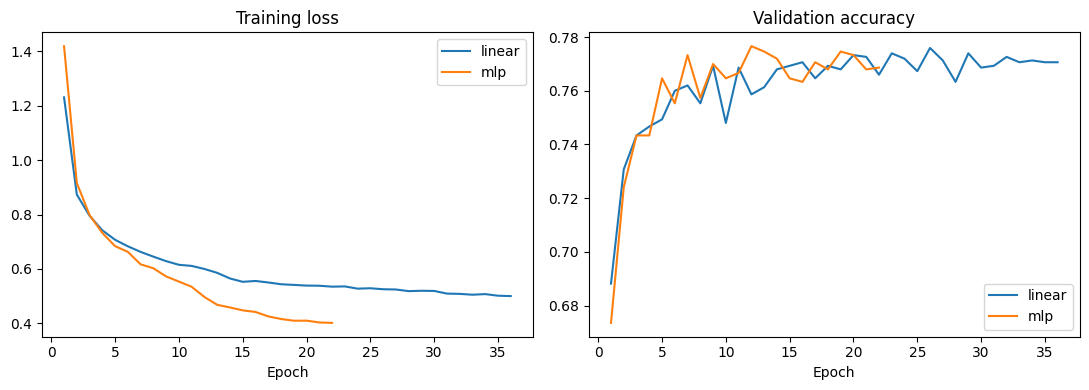

In [13]:
def head_logits(model,X):
    model.eval(); result=[]
    with torch.inference_mode():
        for start in range(0,len(X),512):
            result.append(model(torch.from_numpy(X[start:start+512]).to(DEVICE)).float().cpu().numpy())
    return np.concatenate(result)

counts = np.bincount(y_train,minlength=len(LABELS))
weights = np.sqrt(len(y_train)/(len(LABELS)*counts))
weights = np.clip(weights,.5,3.).astype(np.float32)
weights /= weights.mean()
criterion = nn.CrossEntropyLoss(weight=torch.from_numpy(weights).to(DEVICE),label_smoothing=.05)
CANDIDATES = [
 {'name':'linear','hidden_dim':0,'dropout':.15,'lr':3e-4,'weight_decay':.01},
 {'name':'mlp','hidden_dim':256,'dropout':.4,'lr':3e-4,'weight_decay':.01},
]
best_overall,selected_state,selected_config = None,None,None
selection,curves = [],[]
for candidate in CANDIDATES:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    architecture = {'input_dim':7680,'num_labels':len(LABELS),
                    'hidden_dim':candidate['hidden_dim'],'dropout':candidate['dropout']}
    model = EmotionHead(**architecture).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),lr=candidate['lr'],weight_decay=candidate['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=.5,patience=3)
    loader = DataLoader(TensorDataset(torch.from_numpy(X_train),torch.from_numpy(y_train)),
        batch_size=HEAD_BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=True,
        generator=torch.Generator().manual_seed(SEED))
    best_key,best_state,best_epoch,stale = None,None,None,0
    for epoch in range(1,MAX_EPOCHS+1):
        model.train(); loss_sum=0.
        for xb,yb in loader:
            xb,yb = xb.to(DEVICE,non_blocking=True),yb.to(DEVICE,non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb),yb)
            if not torch.isfinite(loss): raise RuntimeError('Nonfinite training loss')
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.)
            optimizer.step(); loss_sum += loss.item()*len(xb)
        logits = head_logits(model,X_val); pred=logits.argmax(1)
        accuracy = float(accuracy_score(y_val,pred))
        macro = float(f1_score(y_val,pred,labels=np.arange(len(LABELS)),average='macro',zero_division=0))
        key = (accuracy,macro)
        curves.append({'model':candidate['name'],'epoch':epoch,'loss':loss_sum/len(y_train),'val_accuracy':accuracy,'val_macro_f1':macro})
        if best_key is None or key>best_key:
            best_key,best_epoch,stale = key,epoch,0
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else: stale+=1
        scheduler.step(accuracy)
        print(f"{candidate['name']} epoch {epoch:02d} | loss {loss_sum/len(y_train):.4f} | val accuracy {accuracy:.3f} | macro F1 {macro:.3f}")
        if stale>=PATIENCE: break
    selection.append({'name':candidate['name'],'best_epoch':best_epoch,'val_accuracy':best_key[0],'val_macro_f1':best_key[1]})
    # Candidate order gives the linear model preference on an exact metric tie.
    if best_overall is None or best_key>best_overall:
        best_overall,selected_state,selected_config = best_key,best_state,architecture
        selected_name,selected_epoch = candidate['name'],best_epoch
    del model,optimizer,loader
    gc.collect(); torch.cuda.empty_cache()
head = EmotionHead(**selected_config).to(DEVICE)
head.load_state_dict(selected_state,strict=True); head.eval()
display(pd.DataFrame(selection))
history = pd.DataFrame(curves)
fig,axes = plt.subplots(1,2,figsize=(11,4))
for name,part in history.groupby('model'):
    axes[0].plot(part.epoch,part.loss,label=name)
    axes[1].plot(part.epoch,part.val_accuracy,label=name)
axes[0].set(title='Training loss',xlabel='Epoch'); axes[1].set(title='Validation accuracy',xlabel='Epoch')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

### Confidence calibration without changing the chosen emotion
Fit one positive temperature using validation logits after model selection. It changes
confidence, not the highest-scoring label. Validation has also selected epochs/models,
so calibration is approximate and may be optimistic. TESS is absent from validation.
Confidence is not a measured probability of a person's internal emotional state, and
this classifier does not detect unseen emotions or non-speech reliably.

In [14]:
validation_logits = head_logits(head,X_val)
def temperature_loss(log_temperature):
    p = probabilities(validation_logits,np.exp(log_temperature))
    return -np.log(np.maximum(p[np.arange(len(y_val)),y_val],1e-12)).mean()
fit = minimize_scalar(temperature_loss,bounds=(np.log(.05),np.log(20.)),method='bounded')
if not fit.success: raise RuntimeError('Temperature fitting failed')
temperature = float(np.exp(fit.x))
assert np.array_equal(validation_logits.argmax(1),probabilities(validation_logits,temperature).argmax(1))
print('Selected head:',selected_name,'epoch:',selected_epoch,'temperature:',temperature)

Selected head: mlp epoch: 12 temperature: 1.0830575628938528


## N — iNterpret: evaluate the test speakers once
The head, normalization, epoch, and temperature are now fixed. Test labels do not select
any of them. Report overall accuracy, balanced accuracy, macro F1, source-specific results,
and all class supports. Source-specific balanced accuracy averages only classes present
in that source. Equal-source mean accuracy complements pooled accuracy, which is affected
by source sizes. These are held-out speakers from represented corpora, not a new-domain test.

Whisper held-out test features:   0%|          | 0/2902 [00:00<?, ?clip/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,precision,recall,f1-score,support
angry,0.914191,0.626697,0.743624,442.000000
calm,0.923077,0.750000,0.827586,32.000000
disgust,0.736944,0.861991,0.794578,442.000000
fear,0.663194,0.864253,0.750491,442.000000
happy,0.781395,0.380090,0.511416,442.000000
neutral,0.843342,0.782082,0.811558,413.000000
sad,0.707469,0.771493,0.738095,442.000000
surprise,0.562500,0.910931,0.695518,247.000000
accuracy,0.730875,0.730875,0.730875,0.730875
macro avg,0.766514,0.743442,0.734108,2902.000000


,n,accuracy,balanced_accuracy_present_classes,macro_f1_present_classes
RAVDESS,240.0,0.775000,0.789062,0.765388
CREMA-D,1142.0,0.753940,0.756103,0.755693
TESS,1400.0,0.703571,0.703571,0.644015
SAVEE,120.0,0.741667,0.733333,0.744015


Test accuracy: 0.7308752584424535 ; >70%: True


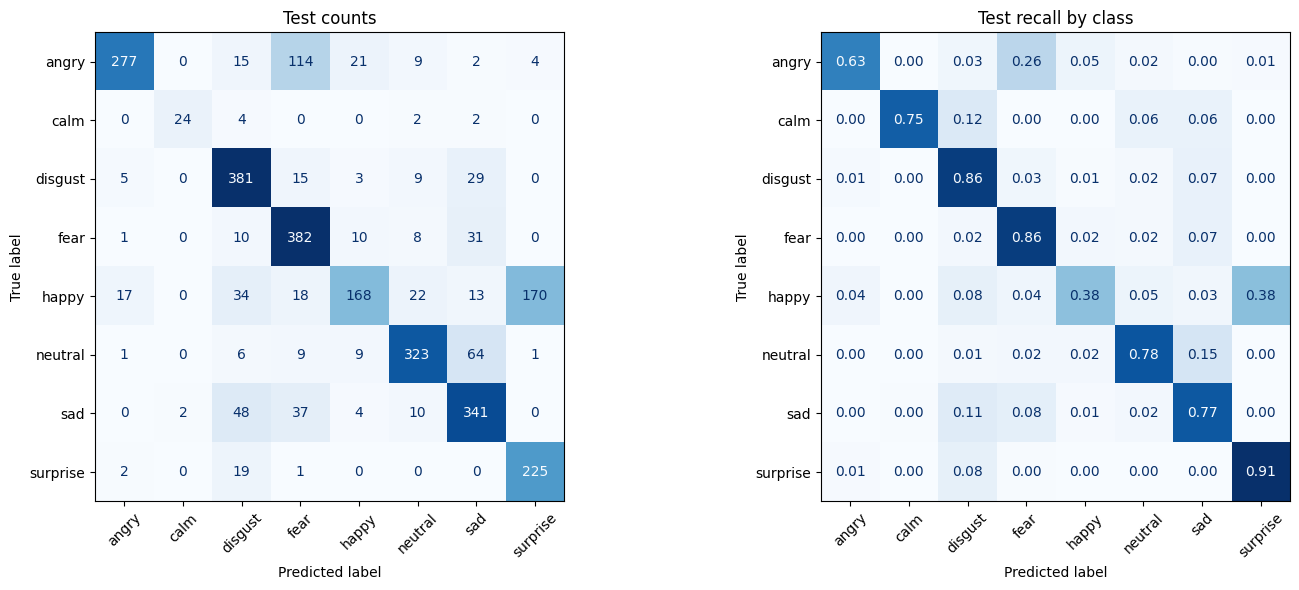

5218

In [15]:
ensure_features(indices['test'],'Whisper held-out test features')
test_ids = indices['test']; test = data.iloc[test_ids].reset_index(drop=True)
X_test = normalize_features(features[test_ids],normal_mean,normal_scale,CONFIG['normalization_clip'])
y_test = y[test_ids]
test_logits = head_logits(head,X_test)
p_test = probabilities(test_logits,temperature); predicted = p_test.argmax(1)
assert np.array_equal(predicted,test_logits.argmax(1))
def summarize(actual,pred):
    present = np.unique(actual)
    return {'n':int(len(actual)), 'accuracy':float(accuracy_score(actual,pred)),
      'balanced_accuracy_present_classes':float(balanced_accuracy_score(actual,pred)),
      'macro_f1_present_classes':float(f1_score(actual,pred,labels=present,average='macro',zero_division=0))}
by_source = {source:summarize(y_test[test.source.to_numpy()==source],predicted[test.source.to_numpy()==source]) for source in PATHS}
report = classification_report(y_test,predicted,labels=np.arange(len(LABELS)),target_names=LABELS,output_dict=True,zero_division=0)
metrics = {'backbone':MODEL_ID,'revision':REVISION,'labels':LABELS,'selected_head':selected_name,
 'selected_epoch':selected_epoch,'validation_selection':selection,'test':summarize(y_test,predicted),
 'test_macro_f1_all_eight':float(f1_score(y_test,predicted,labels=np.arange(len(LABELS)),average='macro',zero_division=0)),
 'test_log_loss':float(log_loss(y_test,p_test,labels=np.arange(len(LABELS)))),
 'by_source':by_source,'equal_source_mean_accuracy':float(np.mean([v['accuracy'] for v in by_source.values()])),
 'classification_report':report,'confusion_matrix':confusion_matrix(y_test,predicted,labels=np.arange(len(LABELS))).tolist(),
 'temperature':temperature,'target_over_70_percent_met':bool(accuracy_score(y_test,predicted)>.70),
 'audit_counts':{str(k):int(v) for k,v in audit.status.value_counts().items()},
 'split_counts':data.groupby(['source','split']).size().unstack(fill_value=0).to_dict('index'),
 'speaker_counts':data.groupby(['source','split']).speaker.nunique().unstack(fill_value=0).to_dict('index'),
 'limitations':['TESS has no validation speaker','Calm occurs only in RAVDESS',
                'Known corpora/scripts; not a new-domain test','Cross-corpus speaker aliases and pretraining overlap are not independently verified']}
display(pd.DataFrame(report).T)
display(pd.DataFrame(by_source).T)
print('Test accuracy:',metrics['test']['accuracy'],'; >70%:',metrics['target_over_70_percent_met'])
fig,axes = plt.subplots(1,2,figsize=(15,6))
for ax,normalize in zip(axes,[None,'true']):
    ConfusionMatrixDisplay.from_predictions(y_test,predicted,labels=np.arange(len(LABELS)),display_labels=LABELS,
        normalize=normalize,ax=ax,cmap='Blues',colorbar=False,xticks_rotation=45,values_format='d' if normalize is None else '.2f')
    ax.set_title('Test counts' if normalize is None else 'Test recall by class')
plt.tight_layout(); fig.savefig(OUT/'confusion_matrix.png',dpi=160,bbox_inches='tight'); plt.show()
(OUT/'evaluation.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')

### Export only the evaluated deployment model
Export one frozen Whisper encoder, one trained head, normalization, label/config metadata,
and an offline predictor. Safetensors stores weights; NPZ stores normalization. No optimizer,
alternate checkpoints, raw audio, or bulk feature cache enters the ZIP. The compact audit
records relative file identities, hash, status, speaker and split so the evaluation can be
reproduced. The deployed head is **not** retrained on validation or test after evaluation.

The export check uses a training clip, never as a new accuracy estimate. It compares the
saved model in a new offline process. CPU FP32 and GPU FP16 inference can differ slightly;
the check uses the same GPU mode with small tolerances for batch-size differences.

In [16]:
# Everything is staged under /kaggle/temp; publish only the ZIP and two evaluation files.
manifest = {'format_version':1,'model_id':MODEL_ID,'model_revision':REVISION,'encoder_frozen':True,
 'labels':LABELS,'head':selected_config,'audio_config':CONFIG,'temperature':temperature,
 'feature_layout':['mean_1280','std_1280','four_ordered_quarter_contrasts_5120'],
 'training_scope':'training speakers only; validation selects epoch/head/temperature; test excluded',
 'selected_head':selected_name,'selected_epoch':selected_epoch,'seed':SEED,'feature_fingerprint':fingerprint,
 'packages':VERSIONS,'python_version':platform.python_version(),'extraction_precision':'FP16 GPU',
 'test_accuracy':metrics['test']['accuracy'],'split_policy':'source-aware speaker separation; TESS 1 train / 0 validation / 1 test'}
save_file({k:v.detach().cpu().contiguous() for k,v in head.state_dict().items()},str(STAGING/'classifier.safetensors'))
np.savez_compressed(STAGING/'normalization.npz',mean=normal_mean,scale=normal_scale)
(STAGING/'manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
shutil.copy2(RUNTIME_PATH,STAGING/'predict.py')
audit.drop(columns=['path']).to_csv(STAGING/'data_audit.csv',index=False)
requirements = ['numpy','scipy','torch','transformers','accelerate','huggingface-hub','safetensors','librosa','soundfile','soxr','imageio-ffmpeg']
(STAGING/'requirements.txt').write_text('\n'.join(f'{name}=={VERSIONS[name].split("+")[0]}' for name in requirements)+'\n',encoding='utf-8')
readme = f"""# Whisper Large V3 speech emotion model

Model: {MODEL_ID} @ {REVISION}. Frozen full audio encoder with a supervised {selected_name} head.
Eight labels: {', '.join(LABELS)}. Test accuracy from this run: {metrics['test']['accuracy']:.4f}.
This is an acted-speech course/research prototype, not a validated assessment of a person's
internal state. Read evaluation.json for per-source results and class support. Confidence
is approximate; unknown emotions, noise, or non-speech may still receive confident labels.

Install requirements.txt, selecting the appropriate CPU/CUDA PyTorch wheel for your machine.
Keep all files together. Example:
    import sys
    sys.path.insert(0, 'whisper_ser_deployment')
    from predict import EmotionPredictor
    predictor = EmotionPredictor('whisper_ser_deployment', device='cpu')
    result = predictor.predict('recording.wav')
Or: python whisper_ser_deployment/predict.py --bundle whisper_ser_deployment --audio recording.wav --device cpu
Reuse one predictor instance. No Hugging Face network access is needed after extraction.
The raw input contract is the same decoder/resampler/boundary trim used in training.
CPU uses FP32 and GPU uses FP16 for Whisper; minor numeric differences are possible.

The eight labels preserve calm, which occurs only in RAVDESS. TESS pleasant surprise maps
to surprise. CREMA-D filename labels describe intended expressions, not necessarily audio
listener consensus. Source IDs are excluded from features. Speaker IDs are namespaced;
cross-corpus aliases and pretrained-data overlap were not independently verified.
TESS has only one training and one test speaker and no validation speaker. Scripts can recur
across speakers. This evaluates speakers from known corpora, not deployment microphones.
No test audio was used to fit normalization, head weights, epochs, or temperature.

Whisper/model terms: https://huggingface.co/openai/whisper-large-v3 (Apache-2.0 listing).
RAVDESS: https://zenodo.org/records/1188976
CREMA-D: https://github.com/CheyneyComputerScience/CREMA-D
TESS: https://doi.org/10.5683/SP2/E8H2MF
SAVEE: https://kahlan.eps.surrey.ac.uk/savee/
This bundle grants no additional rights to the source datasets or dependencies; their
individual terms still apply, including for commercial deployment.
"""
(STAGING/'README.md').write_text(readme,encoding='utf-8')
# Package the existing encoder directly; verify the ZIP before publishing it as a final output.
archive = TEMP/'whisper_ser_deployment.pending.zip'
important = ['classifier.safetensors','normalization.npz','manifest.json','predict.py','requirements.txt','README.md','data_audit.csv']
encoder_files = ['model.safetensors','config.json','preprocessor_config.json','identity.json']
for name in encoder_files:
    if not (ENCODER/name).is_file(): raise FileNotFoundError('Required encoder artifact missing: '+name)
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED,compresslevel=1) as z:
    for name in important: z.write(STAGING/name,'whisper_ser_deployment/'+name)
    for name in encoder_files: z.write(ENCODER/name,'whisper_ser_deployment/encoder/'+name)

probe_index = int(train_ids[0]); probe = data.iloc[probe_index]
probe_X = normalize_features(features[probe_index:probe_index+1],normal_mean,normal_scale,CONFIG['normalization_clip'])
expected = probabilities(head_logits(head,probe_X),temperature)[0]
del extractor
gc.collect(); torch.cuda.empty_cache()
VERIFY = TEMP/'verified_export'
with zipfile.ZipFile(archive) as z: z.extractall(VERIFY)
verified_bundle = VERIFY/'whisper_ser_deployment'
env = dict(os.environ,HF_HUB_OFFLINE='1',TRANSFORMERS_OFFLINE='1',OMP_NUM_THREADS='2',MKL_NUM_THREADS='2')
completed = subprocess.run([sys.executable,str(verified_bundle/'predict.py'),'--bundle',str(verified_bundle),
    '--audio',probe.path,'--device',DEVICE],capture_output=True,text=True,check=True,env=env)
observed = json.loads(completed.stdout)
observed_p = np.array([observed['probabilities'][label] for label in LABELS])
np.testing.assert_allclose(observed_p,expected,rtol=3e-3,atol=3e-4)
assert observed['emotion']==LABELS[int(expected.argmax())]
metrics['offline_export_check'] = 'passed: fresh process, local weights, matching class/probabilities'
(OUT/'evaluation.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')
final_archive = OUT/'whisper_ser_deployment.zip'
shutil.copy2(archive,final_archive)
print('Offline export check passed. Final files:')
for path in [final_archive,OUT/'evaluation.json',OUT/'confusion_matrix.png']: display(FileLink(str(path)))

Offline export check passed. Final files:


/kaggle/working/whisper_ser_deployment.zip

/kaggle/working/evaluation.json

/kaggle/working/confusion_matrix.png

### Reading your results
Use test accuracy together with macro F1, class recall, and per-source metrics. A high
pooled score can hide weak CREMA-D performance or a calm/source shortcut. The original
notebook's random-split score is not a like-for-like baseline. Keep this speaker split
fixed when comparing future revisions; a future external test should use new microphones,
speakers, and spontaneous expressions. Do not relabel difficult clips using model predictions.

### Sources
- [Whisper Large V3](https://huggingface.co/openai/whisper-large-v3): checkpoint and frontend.
- [Pinned Transformers implementation](https://github.com/huggingface/transformers/blob/v4.49.0/src/transformers/models/whisper/modeling_whisper.py): encoder length, stride, and attention-mask behavior.
- [RAVDESS documentation](https://zenodo.org/records/1188976): speaker and filename conventions.
- [CREMA-D documentation](https://github.com/CheyneyComputerScience/CREMA-D): actors, filename expressions, and listener ratings.
- [TESS archive](https://doi.org/10.5683/SP2/E8H2MF): source corpus.
- [SAVEE](https://kahlan.eps.surrey.ac.uk/savee/): source corpus.
- [Leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html): separate fitting from evaluation.

Thresholds, pooling, head sizes, and split proportions are predefined experimental
choices. They are not source-backed promises of a particular accuracy. The final notebook
contains no generated results until you run it.